# Synthetic menu dataset analysis

**Read this before trusting any number in this notebook.** Every crop here comes from the same handwriting-synthesis model (`sjvasquez/handwriting-synthesis`). A test split that also comes from that model does **not** tell you how the fine-tuned OCR model will do on a real photographed menu — it tells you how well it learned this particular generator's stroke statistics. Treat everything below as: *"is this dataset internally sound and free of obvious leakage/quality problems"*, not *"will this model work in production."* The only way to answer the second question is to eventually test on a small set of real photographed handwriting.

What this notebook checks, in order:
1. Basic composition (split sizes, field types, categories)
2. **Style leakage** — confirms the enforced style-disjoint split actually holds (should be zero overlap)
3. **Vocabulary overlap** — reports (does NOT enforce) how much val/test text also appears in training text, since that's a real, not-fully-solved risk in this dataset
4. Text length / character vocabulary coverage — catches characters that appear in val/test but never in train (unlearnable by construction)
5. Image quality — blank, tiny, or degenerate renders that would just be noise to train on
6. Price format and style/bias diversity — sanity-check that the dataset is actually varied, not accidentally dominated by one format or one handwriting identity
7. A visual sample grid across splits
8. A summary readout of everything, with a go/no-go recommendation before you spend GPU time training

In [1]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

# Point this at your generated dataset directory
DATASET_DIR = Path("dataset_synth")

df = pd.read_csv(DATASET_DIR / "manifest.csv")
print(f"{len(df)} total crops")
df.head()

573 total crops


,crop_path,text,split,field_type,style_id,bias,category,vocab_bucket
0,crops\header_00000.png,COFFEE,val,header,7,0.90,Coffee,train
1,crops\header_00001.png,COFFEE,test,header,3,0.70,Coffee,train
2,crops\header_00002.png,COFFEE,train,header,0,0.79,Coffee,train
3,crops\name_00003.png,Espresso,train,name,11,0.94,Coffee,test
4,crops\name_00004.png,Espresso,train,name,2,0.76,Coffee,test


## 1. Basic composition

In [2]:
print("Split sizes:")
print(df["split"].value_counts())
print()
print("By field type x split:")
print(df.groupby(["split", "field_type"]).size().unstack(fill_value=0))
print()
print("By category x split:")
print(df.groupby(["split", "category"]).size().unstack(fill_value=0))

Split sizes:
split
train    409
val       87
test      77
Name: count, dtype: int64

By field type x split:
field_type  header  name  price
split                          
test             4    41     32
train           17   193    199
val              6    39     42

By category x split:
category  Breakfast  Coffee  Desserts  Juices & Smoothies  Pastries  Salads  \
split                                                                         
test             14      12         8                   9        12       4   
train            51      69        42                  31        58      39   
val              10      12        13                  11         5       8   

category  Sandwiches  Soft Drinks  Tea  
split                                   
test               8            3    7  
train             42           31   46  
val               13            5   10  


## 2. Style leakage check

This should show **zero overlap** — the generation script enforces a style-disjoint split (each handwriting identity belongs to exactly one of train/val/test). If this shows any overlap, something is wrong with how the dataset was generated or how splits got merged, and results downstream can't be trusted.

In [3]:
train_styles = set(df[df.split == "train"].style_id)
val_styles = set(df[df.split == "val"].style_id)
test_styles = set(df[df.split == "test"].style_id)

print("train styles:", sorted(train_styles))
print("val styles:  ", sorted(val_styles))
print("test styles: ", sorted(test_styles))

overlap_tv = train_styles & val_styles
overlap_tt = train_styles & test_styles
overlap_vt = val_styles & test_styles

ok = not (overlap_tv or overlap_tt or overlap_vt)
print(f"\n{'PASS' if ok else 'FAIL'}: style overlap train/val={overlap_tv} train/test={overlap_tt} val/test={overlap_vt}")

train styles: [0, 1, 2, 4, 5, 6, 8, 9, 11]
val styles:   [7, 12]
test styles:  [3, 10]

PASS: style overlap train/val=set() train/test=set() val/test=set()


## 3. Vocabulary overlap (reported, not enforced)

Unlike style, exact item text is **not** held disjoint between splits (see `generate_synthetic_dataset.py`'s docstring for why - enforcing both simultaneously starved val/test down to ~2% of the dataset). So this section will almost certainly show real overlap. That's expected - what matters is knowing the number, so you can correctly interpret "the fine-tuned model got X% CER on val" as partly "read new handwriting of *familiar* words" rather than assuming it means "reads genuinely unseen menu text."

In [4]:
train_texts = set(df[df.split == "train"].text)
val_texts = set(df[df.split == "val"].text)
test_texts = set(df[df.split == "test"].text)

val_overlap = val_texts & train_texts
test_overlap = test_texts & train_texts

print(f"val:  {len(val_overlap)}/{len(val_texts)} unique texts also appear verbatim in train ({len(val_overlap)/max(len(val_texts),1):.0%})")
print(f"test: {len(test_overlap)}/{len(test_texts)} unique texts also appear verbatim in train ({len(test_overlap)/max(len(test_texts),1):.0%})")
print()
print("Genuinely unseen-text val examples:", list(val_texts - train_texts)[:10])
print("Genuinely unseen-text test examples:", list(test_texts - train_texts)[:10])
print()
print("vocab_bucket column cross-check (item names reserved for val/test):")
print(df.groupby(["split", "vocab_bucket"]).size().unstack(fill_value=0))

val:  69/72 unique texts also appear verbatim in train (96%)
test: 69/71 unique texts also appear verbatim in train (97%)

Genuinely unseen-text val examples: ['SANDWICHES', '11,23', '9.05 dt']
Genuinely unseen-text test examples: ['11,23', '9.05 dt']

vocab_bucket column cross-check (item names reserved for val/test):
vocab_bucket  test  train  val
split                         
test            10     57   10
train           59    297   53
val              9     63   15


## 4. Text length and character coverage

Any character that shows up in val/test but never in train is unlearnable by construction - the model has literally never seen it. This is worth catching before training, not after a confusing eval result.

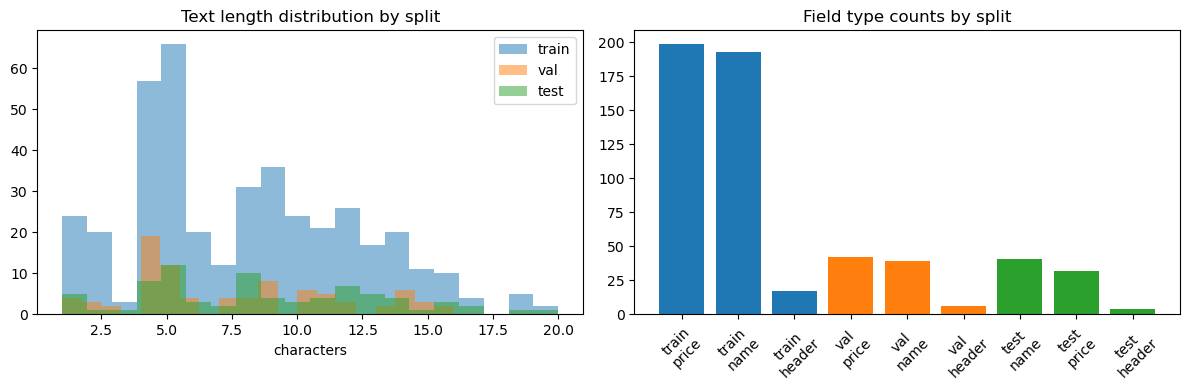

Characters in val but never in train: none
Characters in test but never in train: none


In [6]:
df["text_len"] = df["text"].str.len()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for split in ["train", "val", "test"]:
    subset = df[df.split == split]["text_len"]
    ax[0].hist(subset, bins=20, alpha=0.5, label=split)
ax[0].set_title("Text length distribution by split")
ax[0].set_xlabel("characters")
ax[0].legend()

for split in ["train", "val", "test"]:
    subset = df[df.split == split]["field_type"].value_counts()
    ax[1].bar([f"{split}\n{ft}" for ft in subset.index], subset.values)
ax[1].set_title("Field type counts by split")
ax[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

train_chars = set("".join(df[df.split == "train"].text))
val_chars = set("".join(df[df.split == "val"].text))
test_chars = set("".join(df[df.split == "test"].text))

oov_val = val_chars - train_chars
oov_test = test_chars - train_chars
print(f"Characters in val but never in train: {oov_val if oov_val else 'none'}")
print(f"Characters in test but never in train: {oov_test if oov_test else 'none'}")

## 5. Image quality: blank, tiny, or degenerate crops

0 problem images out of 573 (0.0%)


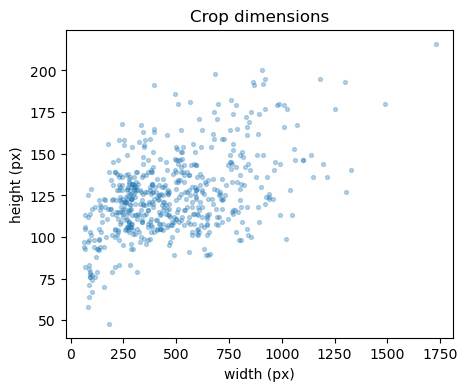

In [7]:
issues = []
sizes = []
for _, row in df.iterrows():
    img_path = DATASET_DIR / row["crop_path"]
    img = cv2.imread(str(img_path))
    if img is None:
        issues.append((row["crop_path"], "unreadable"))
        continue
    h, w = img.shape[:2]
    sizes.append((w, h))
    if img.std() < 5:
        issues.append((row["crop_path"], "near-blank (very low pixel variance)"))
    if h < 10 or w < 10:
        issues.append((row["crop_path"], f"tiny image {w}x{h}"))

print(f"{len(issues)} problem images out of {len(df)} ({len(issues)/len(df):.1%})")
for path, reason in issues[:20]:
    print(" ", path, "-", reason)
if len(issues) > 20:
    print(f"  ... and {len(issues) - 20} more")

sizes = np.array(sizes)
if len(sizes):
    plt.figure(figsize=(5, 4))
    plt.scatter(sizes[:, 0], sizes[:, 1], alpha=0.3, s=8)
    plt.xlabel("width (px)")
    plt.ylabel("height (px)")
    plt.title("Crop dimensions")
    plt.show()

## 6. Price format and style/bias diversity

Checks the dataset isn't accidentally dominated by one price format or one handwriting identity - either would mean the model learns a narrower task than "read handwritten menu text" even within the synthetic domain.

Price format distribution:
format
dot_2dp      0.308
dot_3dp      0.264
integer      0.209
comma_2dp    0.187
other        0.033
Name: proportion, dtype: float64

Prices with a trailing currency mark: 16.5%

Style id distribution (want this roughly even, not dominated by one id):
style_id
0     39
1     46
2     37
3     41
4     45
5     54
6     49
7     39
8     49
9     45
10    36
11    45
12    48
Name: count, dtype: int64



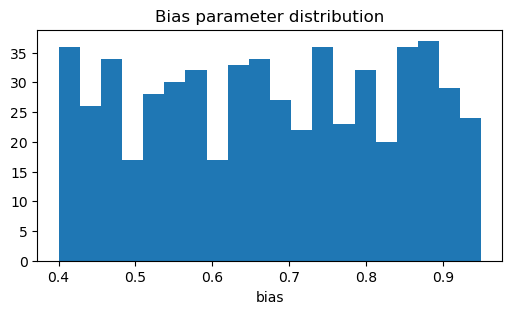

In [8]:
import re

price_rows = df[df.field_type == "price"].copy()

def price_format(text):
    if re.search(r"\d,\d{2}\b", text):
        return "comma_2dp"
    if re.search(r"\d\.\d{3}\b", text):
        return "dot_3dp"
    if re.search(r"\d\.\d{2}\b", text):
        return "dot_2dp"
    if re.search(r"^\d+$", text.strip()):
        return "integer"
    return "other"

price_rows["format"] = price_rows["text"].apply(price_format)
print("Price format distribution:")
print(price_rows["format"].value_counts(normalize=True).round(3))
print()

has_currency_letters = price_rows["text"].str.contains(r"[A-Za-z\u20ac]", regex=True)
print(f"Prices with a trailing currency mark: {has_currency_letters.mean():.1%}")
print()

print("Style id distribution (want this roughly even, not dominated by one id):")
print(df["style_id"].value_counts().sort_index())
print()

plt.figure(figsize=(6, 3))
plt.hist(df["bias"], bins=20)
plt.title("Bias parameter distribution")
plt.xlabel("bias")
plt.show()

## 7. Visual sample grid across splits

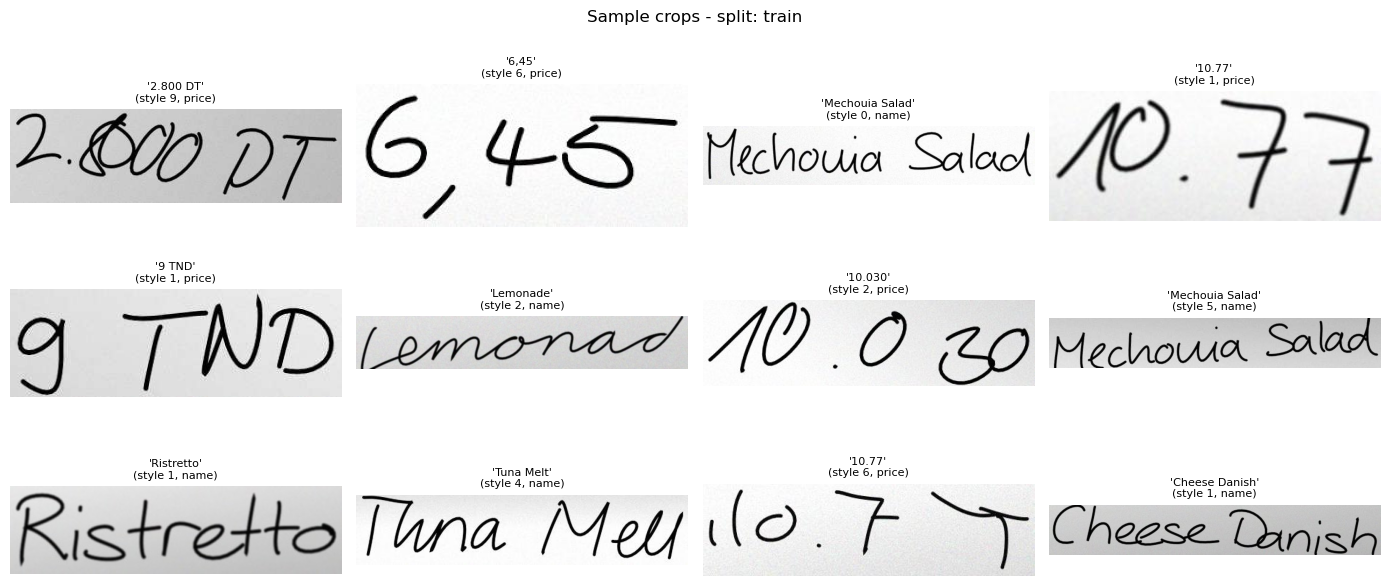

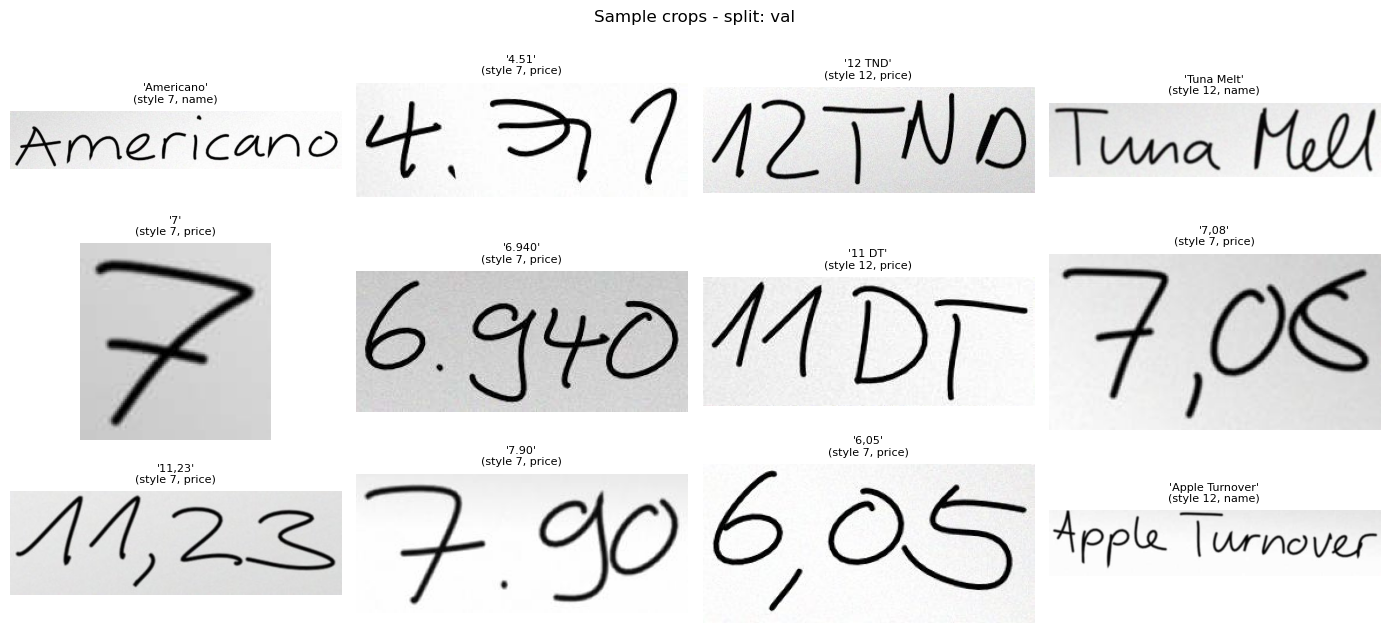

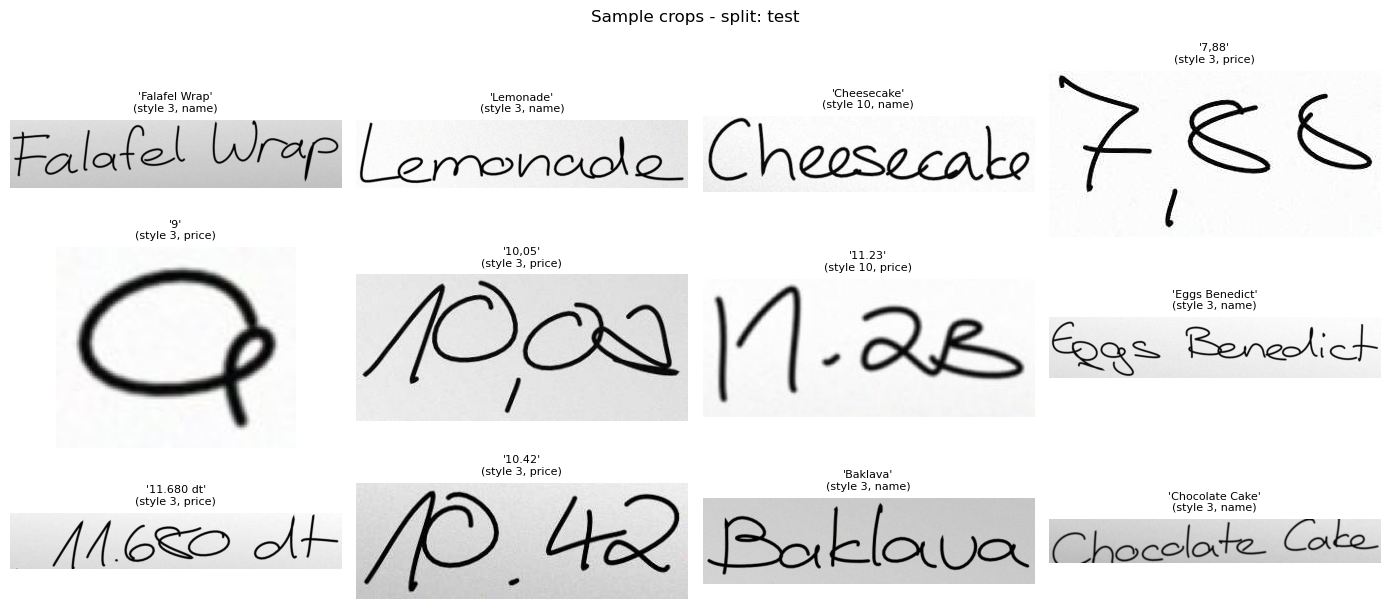

In [9]:
def show_grid(split, n=12, seed=0):
    subset = df[df.split == split].sample(min(n, len(df[df.split == split])), random_state=seed)
    cols = 4
    rows = (len(subset) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, 2.2 * rows))
    axes = np.array(axes).reshape(-1)
    for ax, (_, row) in zip(axes, subset.iterrows()):
        img = cv2.imread(str(DATASET_DIR / row["crop_path"]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(f"{row['text']!r}\n(style {row['style_id']}, {row['field_type']})", fontsize=8)
        ax.axis("off")
    for ax in axes[len(subset):]:
        ax.axis("off")
    fig.suptitle(f"Sample crops - split: {split}")
    plt.tight_layout()
    plt.show()

for split in ["train", "val", "test"]:
    show_grid(split)

## 8. Summary and go/no-go before training

In [10]:
print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(f"Total crops: {len(df)}")
print(f"Split sizes: {dict(df['split'].value_counts())}")
print(f"Style leakage across splits: {'NONE (good)' if ok else 'FOUND - fix before training'}")
print(f"Val text also seen in train: {len(val_overlap)/max(len(val_texts),1):.0%}")
print(f"Test text also seen in train: {len(test_overlap)/max(len(test_texts),1):.0%}")
print(f"OOV characters (val): {oov_val if oov_val else 'none'}")
print(f"OOV characters (test): {oov_test if oov_test else 'none'}")
print(f"Image quality issues: {len(issues)}/{len(df)} ({len(issues)/len(df):.1%})")
print()
print("Read this as: is the dataset internally sound (no leakage, no OOV\n"
      "chars, no broken images, reasonable diversity)? If all checks above\n"
      "look clean, it's reasonable to proceed to train_trocr.py.\n\n"
      "It does NOT tell you the model will work on real photographed\n"
      "menus - only real photos can tell you that. Keep that caveat in\n"
      "mind when reading whatever CER/WER numbers training produces.")

DATASET SUMMARY
Total crops: 573
Split sizes: {'train': np.int64(409), 'val': np.int64(87), 'test': np.int64(77)}
Style leakage across splits: NONE (good)
Val text also seen in train: 96%
Test text also seen in train: 97%
OOV characters (val): none
OOV characters (test): none
Image quality issues: 0/573 (0.0%)

Read this as: is the dataset internally sound (no leakage, no OOV
chars, no broken images, reasonable diversity)? If all checks above
look clean, it's reasonable to proceed to train_trocr.py.

It does NOT tell you the model will work on real photographed
menus - only real photos can tell you that. Keep that caveat in
mind when reading whatever CER/WER numbers training produces.
